In [ ]:
!pip install ultralytics timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.9 MB/s eta 0:00:00


## 0. Download dataset

In [ ]:
# # Download  file license_best.pt
!gdown 1-w_WHinIAGJ75WMJulFPh6lV1F0p9aMW

# # Download  file ocr_crnn_v1.pt
!gdown 1RFQ4FbamRjqNUMwQPXdZoW9610cKQrKs

Downloading...
From: https://drive.google.com/uc?id=1-w_WHinIAGJ75WMJulFPh6lV1F0p9aMW
To: /content/best.pt
100% 5.47M/5.47M [00:00<00:00, 67.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1RFQ4FbamRjqNUMwQPXdZoW9610cKQrKs
From (redirected): https://drive.google.com/uc?id=1RFQ4FbamRjqNUMwQPXdZoW9610cKQrKs&confirm=t&uuid=445d559b-61cc-4739-8b9b-f4f0418712ce
To: /content/ocr_crnn_v1.pt
100% 101M/101M [00:01<00:00, 53.3MB/s] 


## 1. Import libraries

In [ ]:
# %pip install ultralytics
import ultralytics

ultralytics.checks()

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.8/112.6 GB disk)


In [ ]:
import os
import torch
import torch.nn as nn
import timm
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from ultralytics import YOLO

## 2. Load model

### 2.1 Load YOLO

In [ ]:
from ultralytics import YOLO

text_det_model_path = "/content/license_best.pt"
yolo = YOLO(text_det_model_path)

### 2.2 Vocab for Vietnam plates

In [ ]:
plate_chars = "0123456789ABCDEFGHIKLMNPRSTUVXYZ"
blank_char = "-"
chars = blank_char + plate_chars
vocab_size = len(chars)
char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(f"Vocab size: {vocab_size}")
print("Chars:", chars)

Vocab size: 33
Chars: -0123456789ABCDEFGHIKLMNPRSTUVXYZ


### 2.3 Load CRNN

In [ ]:
class CRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size=256, n_layers=3, dropout=0.2):
        super(CRNN, self).__init__()
        # Dùng ResNet34 như lúc bạn train ban đầu (khuyến nghị)
        backbone = timm.create_model("resnet34", in_chans=1, pretrained=False)
        modules = list(backbone.children())[:-2]
        modules.append(nn.AdaptiveAvgPool2d((1, None)))
        self.backbone = nn.Sequential(*modules)

        self.mapSeq = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.gru = nn.GRU(
            512,
            hidden_size,
            n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.out = nn.Sequential(
            nn.Linear(hidden_size * 2, vocab_size),
            nn.LogSoftmax(dim=2)
        )

    @torch.autocast(device_type="cuda")
    def forward(self, x):
        x = self.backbone(x)
        x = x.permute(0, 3, 1, 2)
        x = x.view(x.size(0), x.size(1), -1)  # Flatten the feature map
        x = self.mapSeq(x)
        x, _ = self.gru(x)
        x = self.layer_norm(x)
        x = self.out(x)
        x = x.permute(1, 0, 2)  # Based on CTC

        return x

In [ ]:
hidden_size = 256
n_layers = 3
dropout_prob = 0.2

device = "cuda" if torch.cuda.is_available() else "cpu"

crnn_model = CRNN(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout=dropout_prob,
).to(device)

model_path = "ocr_crnn_v1.pt"
crnn_model.load_state_dict(torch.load(model_path, map_location=device))
crnn_model.eval()
print("Loaded CRNN model successfully!")

Loaded CRNN model successfully!


## 3. Inference

In [ ]:
def decode(encoded_sequences, idx_to_char, blank_idx=0):
    decoded_sequences = []
    for seq in encoded_sequences:
        decoded_label = []
        prev_token = None
        for token in seq:
            token_val = token.item()
            if token_val != blank_idx and token_val != prev_token:
                decoded_label.append(idx_to_char[token_val])
            prev_token = token_val
        decoded_sequences.append("".join(decoded_label))
    return decoded_sequences

def text_detection(img_path, text_det_model):
    results = text_det_model(img_path, verbose=False)[0]
    bboxes = results.boxes.xyxy.cpu().numpy().tolist()
    classes = results.boxes.cls.cpu().numpy().tolist()
    names = results.names
    confs = results.boxes.conf.cpu().numpy().tolist()
    return bboxes, classes, names, confs

def text_recognition(img, data_transforms, text_reg_model, idx_to_char, device):
    transformed_image = data_transforms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = text_reg_model(transformed_image)
        preds = logits.permute(1, 0, 2).argmax(2)
    decoded_text = decode(preds, idx_to_char, blank_idx=0)
    # Xử lý trường hợp không nhận diện được text nào
    return decoded_text[0] if decoded_text else ""

In [ ]:
def predict(img_path, data_transforms, text_det_model, text_reg_model, idx_to_char, device):
    bboxes, classes, names, confs = text_detection(img_path, text_det_model)
    img = Image.open(img_path).convert("RGB")
    predictions = []

    for bbox, cls, conf in zip(bboxes, classes, confs):
        x1, y1, x2, y2 = map(int, bbox)

        # Bắt lỗi crop box nằm ngoài ảnh hoặc kích thước bằng 0
        if x2 <= x1 or y2 <= y1:
            continue

        cropped_image = img.crop((x1, y1, x2, y2))

        transcribed_text = text_recognition(
            cropped_image, data_transforms, text_reg_model, idx_to_char, device
        )
        predictions.append((bbox, names[int(cls)], conf, transcribed_text))

    return img, predictions

def visualize_detections(img, detections):
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    ax = plt.gca()
    for bbox, label, conf, text in detections:
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color="red", linewidth=2)
        ax.add_patch(rect)
        # Tinh chỉnh lại hiển thị text cho rõ ràng hơn
        display_text = f"[{label}] {text} ({conf:.2f})"
        plt.text(x1, max(0, y1-5), display_text, color="white",
                 fontsize=11, fontweight='bold', bbox=dict(facecolor="red", alpha=0.7))
    plt.axis("off")
    plt.show()


Đang xử lý: /content/screenshot_1775033541.png


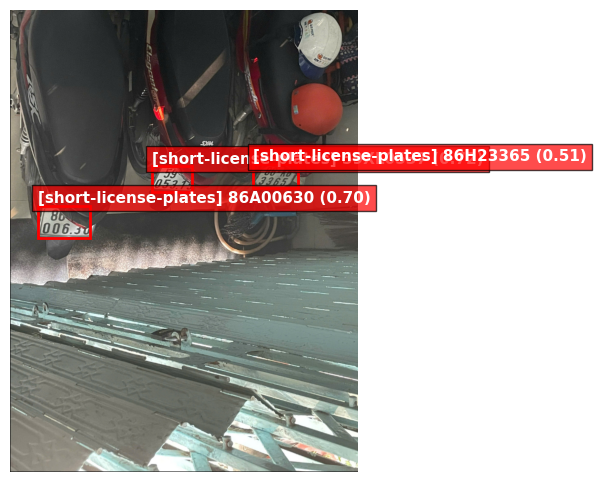

In [ ]:
rec_transforms = transforms.Compose([
    transforms.Resize((100, 420)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# Thư mục chứa ảnh test (đã tải xuống từ phần đầu)
input_path = "/content/screenshot_1775033541.png"

# Đảm bảo thư mục tồn tại trước khi duyệt
if os.path.exists(input_path):
    if os.path.isdir(input_path):
        files = [os.path.join(input_path, f) for f in os.listdir(input_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    else:
        files = [input_path]

    for i, path in enumerate(files):
        if i >= 10: break # Giới hạn 10 ảnh
        print(f"\nĐang xử lý: {path}")
        img_out, preds = predict(path, rec_transforms, yolo, crnn_model, idx_to_char, device)
        visualize_detections(img_out, preds)
else:
    print(f"Lỗi: Không tìm thấy đường dẫn {input_path}. Hãy kiểm tra lại file/thư mục.")